In [1]:
import sys

sys.path.append("../src")

from marginals import *

### 1. load data

In [2]:
df = pd.read_csv(
    "../outputs/cleaned/loan_tape_clean.csv"
)

for col in [
    "origination_date",
    "analysis_end_date"
]:
    df[col] = pd.to_datetime(df[col])
    

### 2. Prepare data

In [3]:
df = prepare_survival_data(df)

### 3. Fit models, plots and comparison table

/Users/megang/Desktop/ml_industry_course_Milan_Italy/.venv/lib/python3.14/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


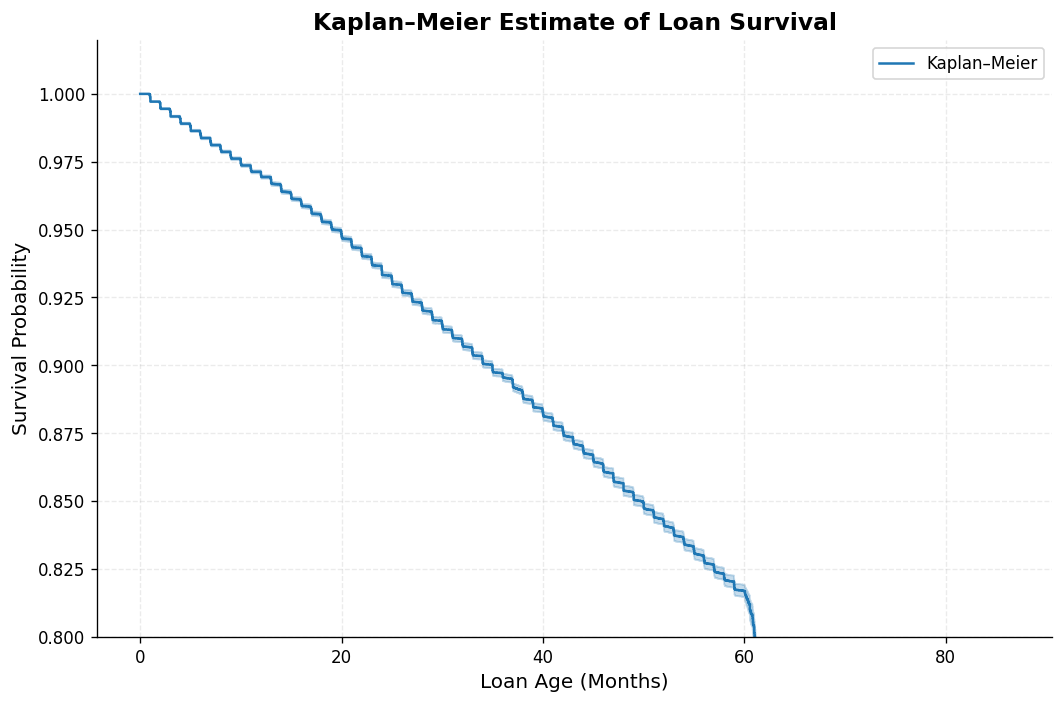

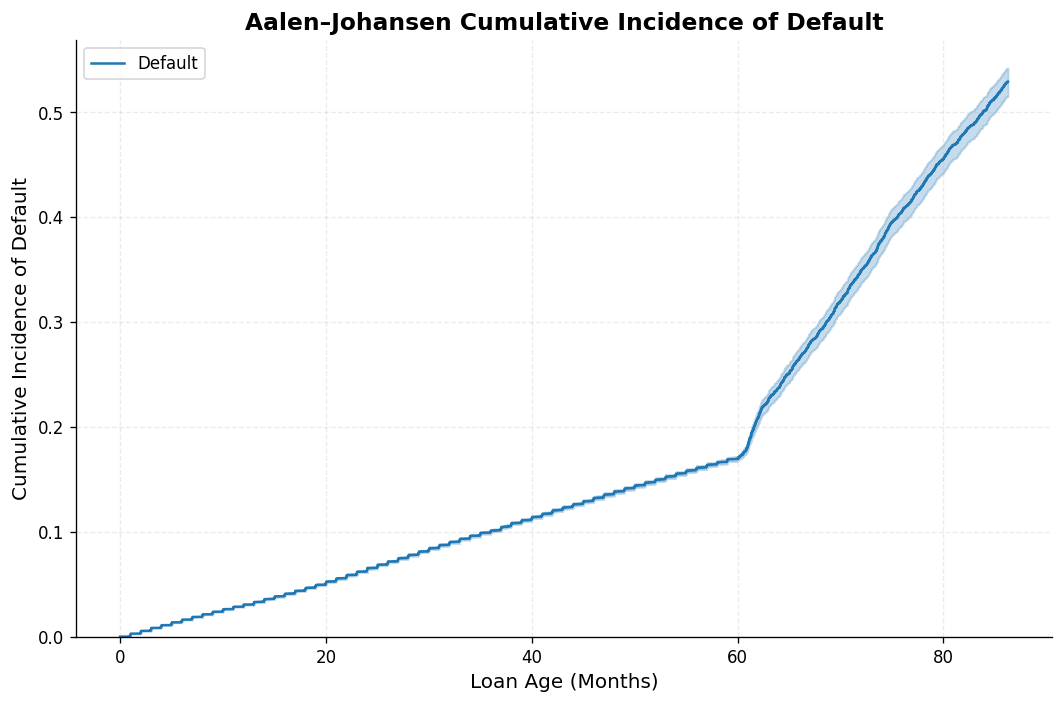

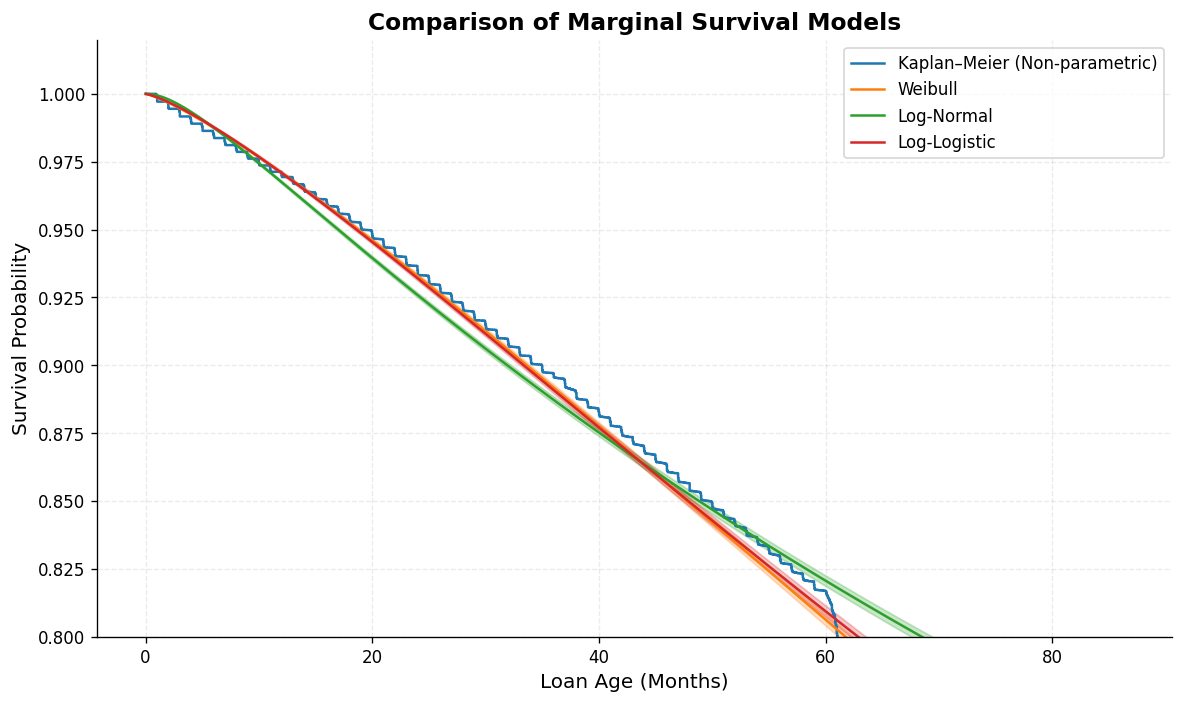


MODEL DIAGNOSTICS


,Model,Log-Likelihood,AIC,BIC,Delta AIC,Delta BIC,AIC Rank,Relative Likelihood,Akaike Weight,BIC Rank,MSE_vs_KM,RMSE_vs_KM
0,Weibull,-190726.74,381457.49,381478.56,0.00,0.00,1,1.0000,1.0000,1,0.027665,0.166327
1,Log-Logistic,-190884.30,381772.60,381793.67,315.12,315.12,2,0.0000,0.0000,2,0.029161,0.170767
2,Log-Normal,-191660.04,383324.08,383345.15,1866.59,1866.59,3,0.0000,0.0000,3,0.033368,0.182670



FITTED MODEL PARAMETERS


,Parameter,Log-Logistic,Log-Normal,Weibull
0,alpha_,185.627733,—,—
1,beta_,1.280001,—,—
2,lambda_,—,—,207.900862
3,mu_,—,5.686784,—
4,rho_,—,—,1.235348
5,sigma_,—,1.735367,—


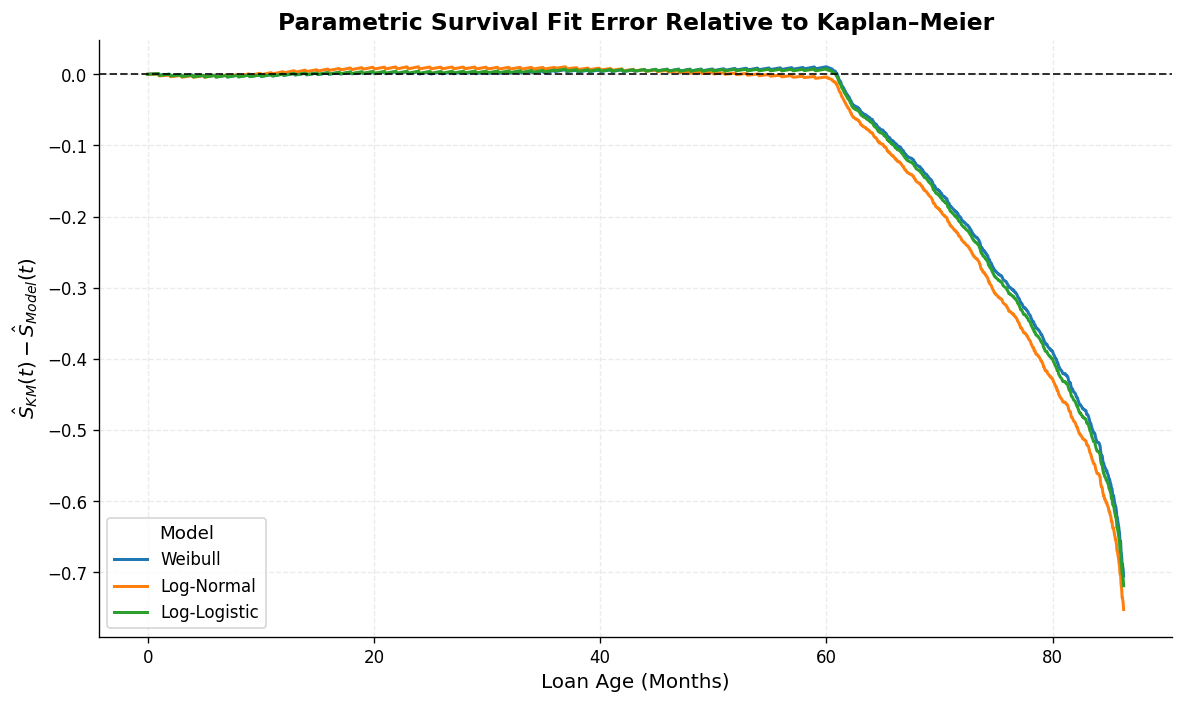

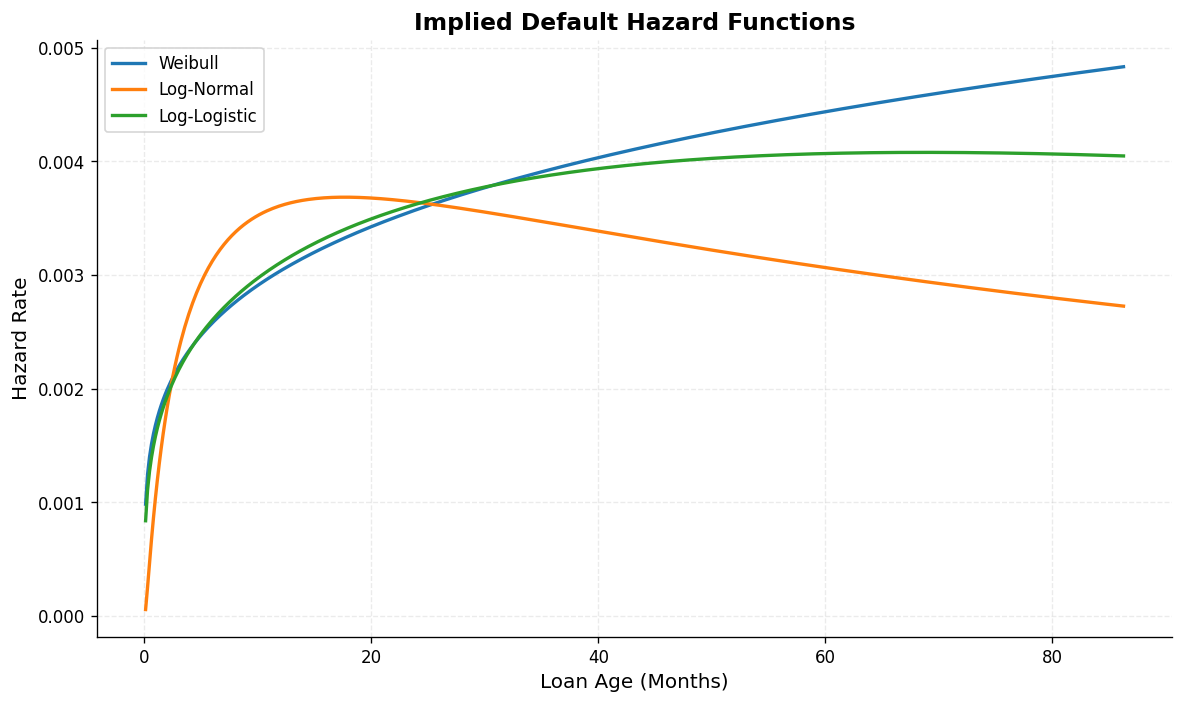

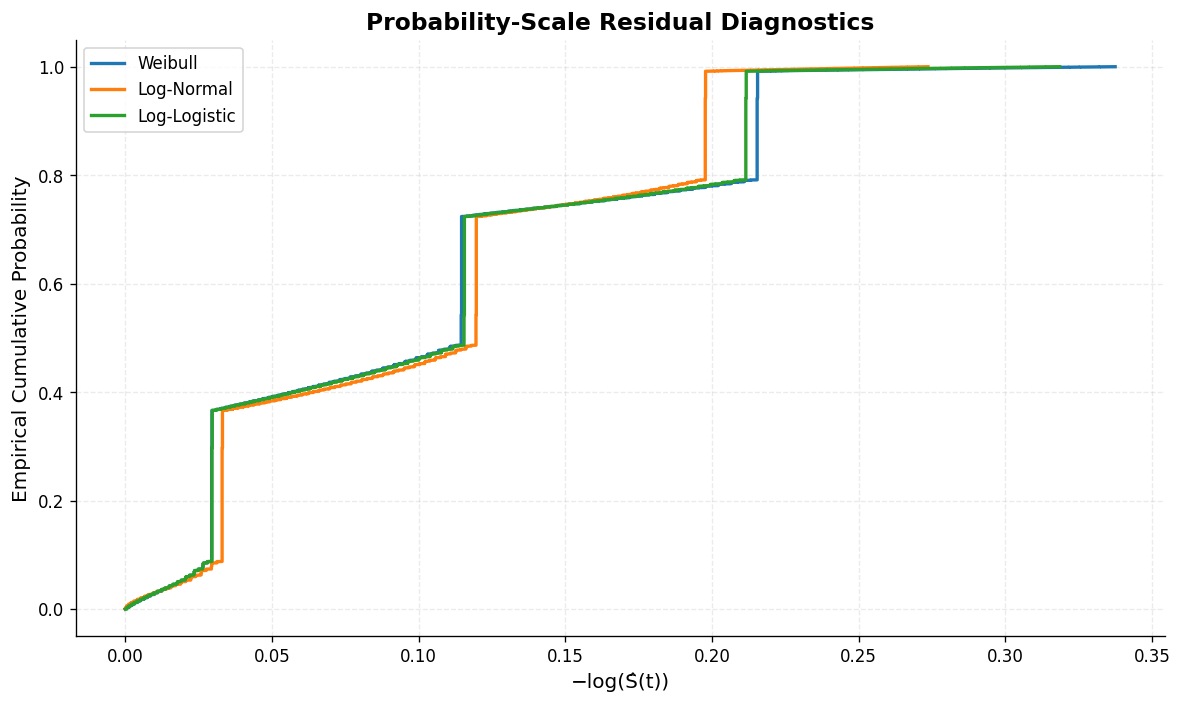


Results saved:
../outputs/tables/marginal_model_diagnostics.csv
../outputs/tables/marginal_model_parameters.csv


In [4]:
# ============================================================
# Fit Models
# ============================================================

kmf = fit_kaplan_meier(df)

ajf = fit_aalen_johansen_default(df)

weibull = fit_weibull(df)

lognormal = fit_lognormal(df)

loglogistic = fit_loglogistic(df)


# ============================================================
# Primary Figures
# ============================================================

plot_kaplan_meier(kmf)

plot_aalen_johansen(ajf)

plot_parametric_models(
    kmf,
    weibull,
    lognormal,
    loglogistic
)


# ============================================================
# Statistical Diagnostics
# ============================================================

diagnostics = comprehensive_model_diagnostics(
    df,
    kmf,
    weibull,
    lognormal,
    loglogistic
)


print("\n" + "=" * 70)
print("MODEL DIAGNOSTICS")
print("=" * 70)

display(
    diagnostics.style.format({
        "Log-Likelihood": "{:.2f}",
        "AIC": "{:.2f}",
        "BIC": "{:.2f}",
        "Delta AIC": "{:.2f}",
        "Delta BIC": "{:.2f}",
        "Relative Likelihood": "{:.4f}",
        "Akaike Weight": "{:.4f}",
    })
)


# ============================================================
# Fitted Parameters
# ============================================================

models = {
    "Weibull": weibull,
    "Log-Normal": lognormal,
    "Log-Logistic": loglogistic
}


parameter_rows = []

for model_name, model in models.items():

    for parameter_name, parameter_value in model.params_.items():

        parameter_rows.append({
            "Model": model_name,
            "Parameter": parameter_name,
            "Estimate": parameter_value
        })


parameters = pd.DataFrame(parameter_rows)


print("\n" + "=" * 70)
print("FITTED MODEL PARAMETERS")
print("=" * 70)


# Wide-format table for easy comparison
parameters_wide = (
    parameters
    .pivot(
        index="Parameter",
        columns="Model",
        values="Estimate"
    )
    .reset_index()
)
parameters_wide.columns.name = None

# Format only numeric columns
numeric_columns = parameters_wide.select_dtypes(
    include="number"
).columns


display(
    parameters_wide.style.format(
        "{:.6f}",
        subset=numeric_columns,
        na_rep="—"
    )
)
# ============================================================
# Diagnostic Figures
# ============================================================

# Survival fit error relative to Kaplan–Meier

plot_survival_fit_error(
    kmf,
    weibull,
    lognormal,
    loglogistic
)


# Implied hazard functions

plot_parametric_hazards(
    weibull,
    lognormal,
    loglogistic,
    max_time=df["duration_months"].max()
)


# Probability-scale residual diagnostics

plot_probability_scale_residuals(
    df,
    weibull,
    lognormal,
    loglogistic
)


# ============================================================
# Save Results
# ============================================================

output_table_dir = Path("../outputs/tables")
output_table_dir.mkdir(
    parents=True,
    exist_ok=True
)


# Save model diagnostics

diagnostics.to_csv(
    output_table_dir / "marginal_model_diagnostics.csv",
    index=False
)


# Save fitted parameters

parameters.to_csv(
    output_table_dir / "marginal_model_parameters.csv",
    index=False
)


print("\nResults saved:")
print(
    output_table_dir / "marginal_model_diagnostics.csv"
)
print(
    output_table_dir / "marginal_model_parameters.csv"
)

### Model A — Overall portfolio Log-Normal

In [5]:
weibull = fit_weibull(df)

print("Overall portfolio model: Weibull")
print(f"shape = {weibull.rho_:.6f}")     # lifelines names Weibull shape 'rho_'
print(f"scale = {weibull.lambda_:.6f}")  # and scale 'lambda_'
print(f"AIC   = {weibull.AIC_:.2f}")
print(f"BIC   = {weibull.BIC_:.2f}")

Overall portfolio model: Weibull
shape = 1.235348
scale = 207.900862
AIC   = 381457.49
BIC   = 381478.56


In [6]:
# ============================================================
# Segmented Model: Overall AIC / BIC
# ============================================================

def calculate_segmented_information_criteria(
    results,
    n_parameters_per_group=2
):

    number_of_groups = len(results)

    total_loglik = results["Log-Likelihood"].sum()

    total_parameters = (
        number_of_groups
        * n_parameters_per_group
    )

    aic = (
        -2 * total_loglik
        + 2 * total_parameters
    )

    bic = (
        -2 * total_loglik
        + total_parameters * np.log(
            results["N"].sum()
        )
    )

    return {
        "Groups": number_of_groups,
        "Parameters": total_parameters,
        "Log-Likelihood": total_loglik,
        "AIC": aic,
        "BIC": bic
    }

In [7]:
# ============================================================
# FICO bands
# ============================================================

def create_fico_band(x):

    if pd.isna(x):
        return np.nan

    if x < 580:
        return "<580"

    elif x < 670:
        return "580-669"

    elif x < 740:
        return "670-739"

    elif x < 800:
        return "740-799"

    else:
        return "800+"

df["fico_band"] = (
    df["fico_score"]
    .apply(create_fico_band)
)



In [8]:
from lifelines import WeibullFitter

def fit_weibull_by_group(df, group_col):
    results = []
    fitted_models = {}

    for group, group_df in df.groupby(group_col, observed=True):
        group_df = group_df[group_df["duration_months"] > 0].copy()

        if group_df["default_event"].sum() == 0:
            print(f"Skipping {group_col}={group}: no default events.")
            continue

        model = WeibullFitter()
        model.fit(
            durations=group_df["duration_months"],
            event_observed=group_df["default_event"],
            label=f"Weibull: {group}"
        )
        fitted_models[group] = model

        results.append({
            "Group": group,
            "N": len(group_df),
            "Defaults": group_df["default_event"].sum(),
            "Default Rate": group_df["default_event"].mean(),
            "shape": model.rho_,
            "scale": model.lambda_,
            "Log-Likelihood": model.log_likelihood_,
            "AIC": model.AIC_,
            "BIC": model.BIC_
        })

    results = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results, fitted_models

# Region segmentation
region_results_w, region_models_w = fit_weibull_by_group(df, "region")
display(region_results_w)

# FICO segmentation
fico_results_w, fico_models_w = fit_weibull_by_group(df, "fico_band")
display(fico_results_w)

# amortization-type segmentation, motivated by the maturity-spike finding
amort_results_w, amort_models_w = fit_weibull_by_group(df, "amortization_type")
display(amort_results_w)

# term segmentation, motivated by the maturity-spike finding
term_results, term_models = fit_weibull_by_group(df, "term")
display(term_results)

# Total AIC/BIC for each segmentation scheme
region_ic_w = calculate_segmented_information_criteria(region_results_w)
fico_ic_w = calculate_segmented_information_criteria(fico_results_w)
amort_ic_w = calculate_segmented_information_criteria(amort_results_w)
term_ic = calculate_segmented_information_criteria(term_results)

comparison_w = pd.DataFrame([
    {"Model": "Overall Weibull", "Parameters": 2,
     "Log-Likelihood": weibull.log_likelihood_, "AIC": weibull.AIC_, "BIC": weibull.BIC_},
    {"Model": "Region-segmented Weibull", **region_ic_w},
    {"Model": "FICO-segmented Weibull", **fico_ic_w},
    {"Model": "Amortization-segmented Weibull", **amort_ic_w},
    {"Model": "Term-segmented Weibull", **term_ic}
])
comparison_w["Delta AIC"] = comparison_w["AIC"] - comparison_w["AIC"].min()
display(comparison_w.sort_values("AIC"))

,Group,N,Defaults,Default Rate,shape,scale,Log-Likelihood,AIC,BIC
0,Southeast,72496,4626,0.063810,2.603327,115.782055,-31094.665785,62193.331570,62211.714143
1,Southwest,71804,6232,0.086792,1.182252,260.147834,-42907.879006,85819.758013,85838.121403
2,Pacific,71073,6284,0.088416,1.167301,262.381452,-43171.093530,86346.187061,86364.529986
3,Northeast,62494,11334,0.181361,1.074999,145.855344,-68930.632886,137865.265773,137883.351425


,Group,N,Defaults,Default Rate,shape,scale,Log-Likelihood,AIC,BIC
0,800+,25053,1425,0.056879,1.443613,256.310957,-10356.244491,20716.488982,20732.746480
1,740-799,29840,1707,0.057205,1.394607,272.427402,-12427.455186,24858.910373,24875.517583
2,670-739,34254,1943,0.056723,1.432946,260.444336,-14135.633899,28275.267798,28292.150915
3,580-669,44192,2544,0.057567,1.386856,272.232413,-18490.854281,36985.708562,37003.101160
4,<580,138986,20311,0.146137,1.195284,157.805497,-128280.668479,256565.336957,256585.021214


,Group,N,Defaults,Default Rate,shape,scale,Log-Likelihood,AIC,BIC
0,Italian,92633,9394,0.101411,1.224571,211.756876,-62994.541668,125993.083335,126011.956137
1,French,92596,9527,0.102888,1.243419,205.506153,-63777.262192,127558.524384,127577.396387
2,Bullet,92638,9555,0.103143,1.238037,206.572503,-63953.937645,127911.875289,127930.748199


,Group,N,Defaults,Default Rate,shape,scale,Log-Likelihood,AIC,BIC
0,12,91799,3806,0.041460,2.119723,55.155863,-24250.909821,48505.819641,48524.674355
1,36,92936,9594,0.103232,1.299440,188.144650,-64400.290852,128804.581704,128823.461037
2,60,93132,15076,0.161878,1.214084,227.414178,-101193.200053,202390.400105,202409.283652


,Model,Parameters,Log-Likelihood,AIC,BIC,Groups,Delta AIC
2,FICO-segmented Weibull,10,-183690.856336,367401.712672,367506.860187,5.0,0.000000
1,Region-segmented Weibull,8,-186104.271208,372224.542416,372308.821599,4.0,4822.829744
4,Term-segmented Weibull,6,-189844.400725,379700.801451,379764.010838,3.0,12299.088778
0,Overall Weibull,2,-190726.744575,381457.489149,381478.558945,NaN,14055.776477
3,Amortization-segmented Weibull,6,-190725.741504,381463.483008,381526.692396,3.0,14061.770336


FICO segmentation was carried forward into the dependence analysis because it provided the best marginal fit. The FICO-segmented Log-Normal model reduced AIC by approximately 15,000 relative to the pooled model and by approximately 8,000 relative to regional segmentation. This suggests that borrower credit quality explains substantially more variation in default timing than geographic segmentation.